In [1]:
import torch

In [2]:
import torch.nn as nn

In [4]:
conv = nn.Conv2d(3, 16, kernel_size=(3,3))

In [5]:
conv

Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [6]:
conv.weight.shape

torch.Size([16, 3, 3, 3])

In [7]:
conv.bias.shape

torch.Size([16])

In [8]:
from torchvision import datasets

data_path = '../chapter7/data'

cifar10 = datasets.CIFAR10(data_path, train=True, download=False)
cifar10_val = datasets.CIFAR10(data_path, train=False, download=False)

In [9]:
label_map = {0:0, 2:1}

cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0,2]]
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0,2]]

In [11]:
from torchvision import transforms

to_tensor = transforms.ToTensor()

In [13]:
cifar2_tensor = [(to_tensor(img), label) for img, label in cifar2]
cifar2_val_tensor = [(to_tensor(img), label) for img, label in cifar2_val]

In [18]:
img, _ = cifar2_tensor[0]

In [23]:
output = conv(img.unsqueeze(0))

In [20]:
img.shape

torch.Size([3, 32, 32])

In [26]:
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

In [27]:
conv = nn.Conv2d(3, 16, kernel_size=(3,3), padding=1)

In [28]:
output = conv(img.unsqueeze(0))

In [ ]:
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 32, 32]))

In [32]:
import matplotlib.pyplot as plt

In [33]:
def plot_images(input, output, img_name=""):
    # Create a figure with two subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.8))

    # Left subplot (input)
    ax1.imshow(input.mean(0), cmap='gray')
    ax1.set_title('input')
    ax1.set_xlim([0, 31])  # Set x-axis limits
    ax1.set_ylim([31, 0])  # Invert the y-axis

    # Right subplot (output)
    ax2.imshow(output[0, 0].detach(), cmap='gray')
    ax2.set_title('output')
    ax2.set_xlim([0, 31])  # Set x-axis limits
    ax2.set_ylim([31, 0])  # Invert the y-axis

    if img_name:
        plt.savefig(img_name)  # bookskip
    plt.show()

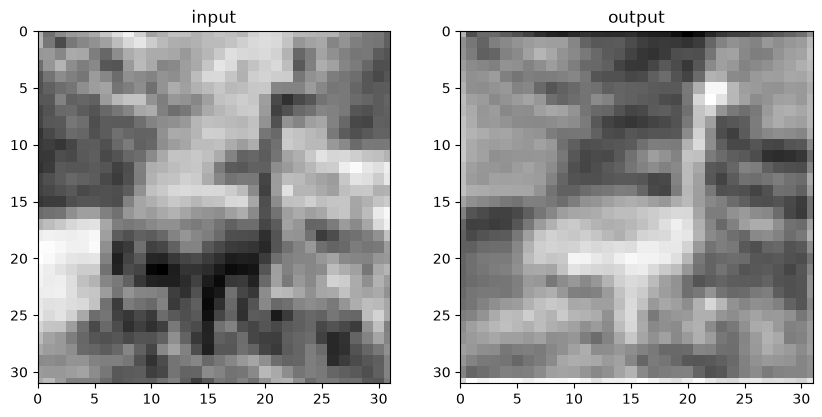

In [34]:
plot_images(img, output)

In [35]:
with torch.no_grad():
    conv.bias.zero_()

In [37]:
with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)

In [39]:
output = conv(img.unsqueeze(0))

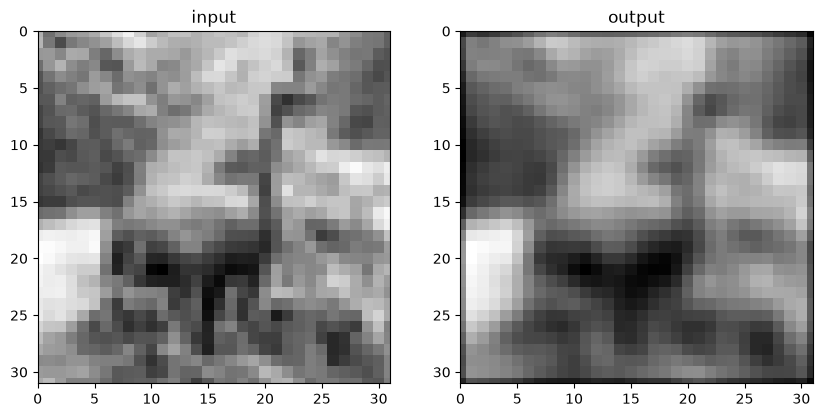

In [40]:
plot_images(img, output)

In [42]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1)

with torch.no_grad():
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0], [-1.0, 0.0, 1.0]])

In [43]:
with torch.no_grad():
    conv.bias.zero_()

In [44]:
output = conv(img.unsqueeze(0))

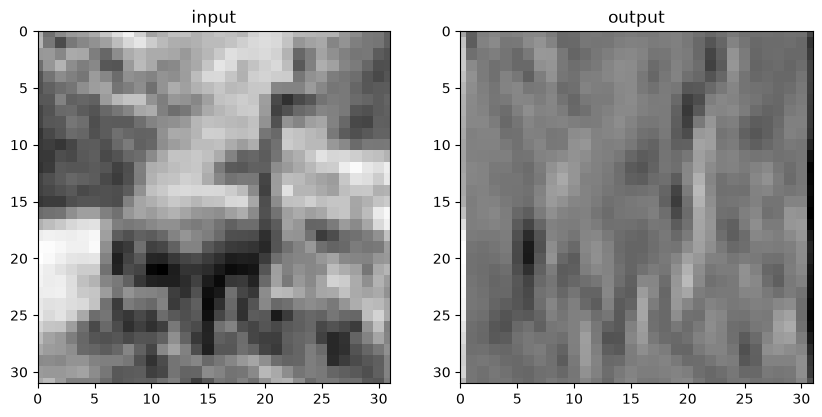

In [45]:
plot_images(img, output)

In [46]:
pool = nn.MaxPool2d(2)

output = pool(img.unsqueeze(0))

In [49]:
img.unsqueeze(0).shape, output.shape

(torch.Size([1, 3, 32, 32]), torch.Size([1, 3, 16, 16]))

In [51]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1), # 16 * 32 * 32
    nn.Tanh(),
    nn.MaxPool2d(2), # 16 * 16 * 16,
    nn.Conv2d(16, 8, kernel_size=3, padding=1),
    nn.Tanh(),
    nn.MaxPool2d(2), # 8 * 8 * 8
    nn.Linear(8*8*8, 32),
    nn.Tanh(),
    nn.Linear(32, 2)
)

In [52]:
model(img.unsqueeze(0))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (64x8 and 512x32)

In [53]:
# we need to custom to solve the above problem

In [57]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(512, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 512)
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [58]:
model = Net()

In [59]:
out = model(img.unsqueeze(0))

In [61]:
out

tensor([[-0.0438,  0.1332]], grad_fn=<AddmmBackward0>)

Wen can use functional API to reduce the stateful mechanism of modules in pytorch

In [65]:
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8*8*8, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8*8*8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [72]:
import datetime

def training_loop(n_epchos, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epchos+1):
        start_time = datetime.datetime.now()
        loss_train = 0
        for imgs, labels in train_loader:
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch==1 or epoch % 10 == 0:
            print(f'{datetime.datetime.now()} Epoch: {epoch}, Loss: {loss_train/len(train_loader)}, Time: {epoch_duration}')

In [73]:
train_loader = torch.utils.data.DataLoader(cifar2_tensor, batch_size=64, shuffle=True)

In [74]:
import torch.optim as optim

model = Net()
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epchos=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

2026-09-11 09:04:25.387678 Epoch: 1, Loss: 0.690576319102269, Time: 3.421154
2026-09-11 09:04:55.338798 Epoch: 10, Loss: 0.46233077261857924, Time: 3.310105
2026-09-11 09:05:28.822905 Epoch: 20, Loss: 0.3537397769985685, Time: 3.390336
2026-09-11 09:06:03.254514 Epoch: 30, Loss: 0.3247424796888023, Time: 3.433409
2026-09-11 09:06:37.479458 Epoch: 40, Loss: 0.3104715794799434, Time: 3.380849
2026-09-11 09:07:11.112966 Epoch: 50, Loss: 0.2985452869135863, Time: 3.317511
2026-09-11 09:07:44.810112 Epoch: 60, Loss: 0.2856071574293124, Time: 3.384366
2026-09-11 09:08:19.040320 Epoch: 70, Loss: 0.2760276584678395, Time: 3.474129
2026-09-11 09:08:53.190193 Epoch: 80, Loss: 0.2656554342455165, Time: 3.426977
2026-09-11 09:09:27.320682 Epoch: 90, Loss: 0.2540681374490641, Time: 3.364152
2026-09-11 09:10:01.437234 Epoch: 100, Loss: 0.24113184621759282, Time: 3.419874


In [83]:
train_loader = torch.utils.data.DataLoader(
    cifar2_tensor, batch_size=64, shuffle=False
)

val_loader = torch.utils.data.DataLoader(
    cifar2_val_tensor, batch_size=64, shuffle=False
)

def validate(model, train_loader, val_loader):
    for name, loader in [('train', train_loader), ('val', val_loader)]:
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, labels in loader:
                outputs = model(imgs)
                _, predicted = torch.max(outputs, dim=1)
                total += labels.shape[0]
                correct += int((predicted == labels).sum())
        print(f'Accuracy {name}: {correct/total}')

In [84]:
validate(model, train_loader=train_loader, val_loader=val_loader)

Accuracy train: 0.8983
Accuracy val: 0.8755


In [87]:
[p.numel() for p in model.parameters()]

[432, 16, 1152, 8, 16384, 32, 64, 2]

Save and load model

In [96]:
torch.save(model.state_dict(), data_path + "/cnn_births_and_airplaines.pt")

In [100]:
loaded_model = Net()
loaded_model.load_state_dict(torch.load(data_path + '/cnn_births_and_airplaines.pt'))

<All keys matched successfully>

In [101]:
device = (torch.device('mps') if torch.mps.is_available() else torch.device('cpu'))

In [107]:
import datetime

def training_loop(n_epchos, optimizer, model, loss_fn, train_loader):
    for epoch in range(1, n_epchos+1):
        start_time = datetime.datetime.now()
        loss_train = 0
        for imgs, labels in train_loader:
            imgs = imgs.to(device=device)
            labels = labels.to(device=device)
            outputs = model(imgs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            loss_train += loss.item()
        end_time = datetime.datetime.now()
        epoch_duration = (end_time - start_time).total_seconds()
        if epoch==1 or epoch % 10 == 0:
            print(f'{datetime.datetime.now()} Epoch: {epoch}, Loss: {loss_train/len(train_loader)}, Time: {epoch_duration}')

In [108]:
train_loader = torch.utils.data.DataLoader(cifar2_tensor, batch_size=64, shuffle=True)

model = Net().to(device=device)
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

training_loop(
    n_epchos=100,
    optimizer=optimizer,
    model=model,
    loss_fn=loss_fn,
    train_loader=train_loader
)

2026-09-11 09:40:07.362574 Epoch: 1, Loss: 0.6725315816083531, Time: 3.261024
2026-09-11 09:40:12.967256 Epoch: 10, Loss: 0.45516865078810675, Time: 0.643818
2026-09-11 09:40:19.562424 Epoch: 20, Loss: 0.3525765187990893, Time: 0.660974
2026-09-11 09:40:26.115170 Epoch: 30, Loss: 0.3234509024650428, Time: 0.660231
2026-09-11 09:40:32.709673 Epoch: 40, Loss: 0.30103884950564924, Time: 0.682874
2026-09-11 09:40:39.297668 Epoch: 50, Loss: 0.2805798158144495, Time: 0.700169
2026-09-11 09:40:46.247076 Epoch: 60, Loss: 0.267856928905484, Time: 0.730211
2026-09-11 09:40:52.686848 Epoch: 70, Loss: 0.2540447703402513, Time: 0.648153
2026-09-11 09:40:59.175561 Epoch: 80, Loss: 0.2441877708028836, Time: 0.654934
2026-09-11 09:41:05.754998 Epoch: 90, Loss: 0.23435598365060842, Time: 0.636536
2026-09-11 09:41:12.270520 Epoch: 100, Loss: 0.21936187266733995, Time: 0.651014


In [111]:
class NetDropout(nn.Module):
    def __init__(self, n_chans1=32):
        super().__init__()
        self.n_chans1 = n_chans1
        self.conv1 = nn.Conv2d(3, n_chans1, kernel_size=3, padding=1)
        self.conv1_dropout = nn.Dropout2d(p=0.4)
        self.conv2 = nn.Conv2d(n_chans1, n_chans1 // 2, kernel_size=3,
                               padding=1)
        self.conv2_dropout = nn.Dropout2d(p=0.4)
        self.fc1 = nn.Linear(8 * 8 * n_chans1 // 2, 32)
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = self.conv1_dropout(out)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = self.conv2_dropout(out)
        out = out.view(-1, 8 * 8 * self.n_chans1 // 2)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [112]:
model_dropout = NetDropout()

In [113]:
model_dropout.train()

NetDropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_dropout): Dropout2d(p=0.4, inplace=False)
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_dropout): Dropout2d(p=0.4, inplace=False)
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

In [114]:
model_dropout.eval()

NetDropout(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_dropout): Dropout2d(p=0.4, inplace=False)
  (conv2): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_dropout): Dropout2d(p=0.4, inplace=False)
  (fc1): Linear(in_features=1024, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)